# Retail Sales Performance Analysis
**Tools:** SQL (SQLite) · Python · pandas · matplotlib  
**Dataset:** Superstore Sales (9,994 transactions, 2014–2017)

## Business Problem
A retail business wants to understand which products, categories, and discount 
strategies are driving or destroying profitability — and identify seasonal trends.

In [1]:
import sqlite3
import pandas as pd

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')
conn = sqlite3.connect('Sample - Superstore.db')
df.to_sql('orders', conn, if_exists='replace', index=False)

print("Done! Rows loaded:", len(df))
print(df.columns.tolist())

Done! Rows loaded: 9994
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


## 1. Category Performance
Which broad category drives the most revenue and profit?

In [2]:
# Revenue by Category
category_revenue = pd.read_sql_query("""
    SELECT Category, 
           ROUND(SUM(Sales), 2) AS total_revenue,
           ROUND(SUM(Profit), 2) AS total_profit,
           ROUND(SUM(Profit)/SUM(Sales)*100, 2) AS margin_pct
    FROM orders
    GROUP BY Category
    ORDER BY total_revenue DESC
""", conn)

print(category_revenue)

          Category  total_revenue  total_profit  margin_pct
0       Technology      836154.03     145454.95       17.40
1        Furniture      741999.80      18451.27        2.49
2  Office Supplies      719047.03     122490.80       17.04


## 2. Sub-Category Drill-Down
Which specific product lines are profitable and which are loss-making?

In [3]:
# Sub-Category profitability -- find the losers
subcategory = pd.read_sql_query("""
    SELECT "Sub-Category",
           Category,
           ROUND(SUM(Sales), 2) AS revenue,
           ROUND(SUM(Profit), 2) AS profit
    FROM orders
    GROUP BY "Sub-Category"
    ORDER BY profit ASC
""", conn)

print(subcategory)

   Sub-Category         Category    revenue    profit
0        Tables        Furniture  206965.53 -17725.48
1     Bookcases        Furniture  114880.00  -3472.56
2      Supplies  Office Supplies   46673.54  -1189.10
3     Fasteners  Office Supplies    3024.28    949.52
4      Machines       Technology  189238.63   3384.76
5        Labels  Office Supplies   12486.31   5546.25
6           Art  Office Supplies   27118.79   6527.79
7     Envelopes  Office Supplies   16476.40   6964.18
8   Furnishings        Furniture   91705.16  13059.14
9    Appliances  Office Supplies  107532.16  18138.01
10      Storage  Office Supplies  223843.61  21278.83
11       Chairs        Furniture  328449.10  26590.17
12      Binders  Office Supplies  203412.73  30221.76
13        Paper  Office Supplies   78479.21  34053.57
14  Accessories       Technology  167380.32  41936.64
15       Phones       Technology  330007.05  44515.73
16      Copiers       Technology  149528.03  55617.82


## 3. Discount Impact Analysis
Does discounting help or hurt the business?

In [4]:
# Discount vs Profit -- does discounting hurt the business?
discount_analysis = pd.read_sql_query("""
    SELECT 
        CASE 
            WHEN Discount = 0 THEN 'No Discount'
            WHEN Discount <= 0.10 THEN '1-10%'
            WHEN Discount <= 0.20 THEN '11-20%'
            WHEN Discount <= 0.40 THEN '21-40%'
            ELSE 'Over 40%'
        END AS discount_band,
        COUNT(*) AS num_orders,
        ROUND(AVG(Profit), 2) AS avg_profit,
        ROUND(SUM(Profit), 2) AS total_profit
    FROM orders
    GROUP BY discount_band
    ORDER BY avg_profit DESC
""", conn)

print(discount_analysis)

  discount_band  num_orders  avg_profit  total_profit
0         1-10%          94       96.06       9029.18
1   No Discount        4798       66.90     320987.60
2        11-20%        3709       24.74      91756.30
3        21-40%         460      -77.86     -35817.47
4      Over 40%         933     -106.71     -99558.59


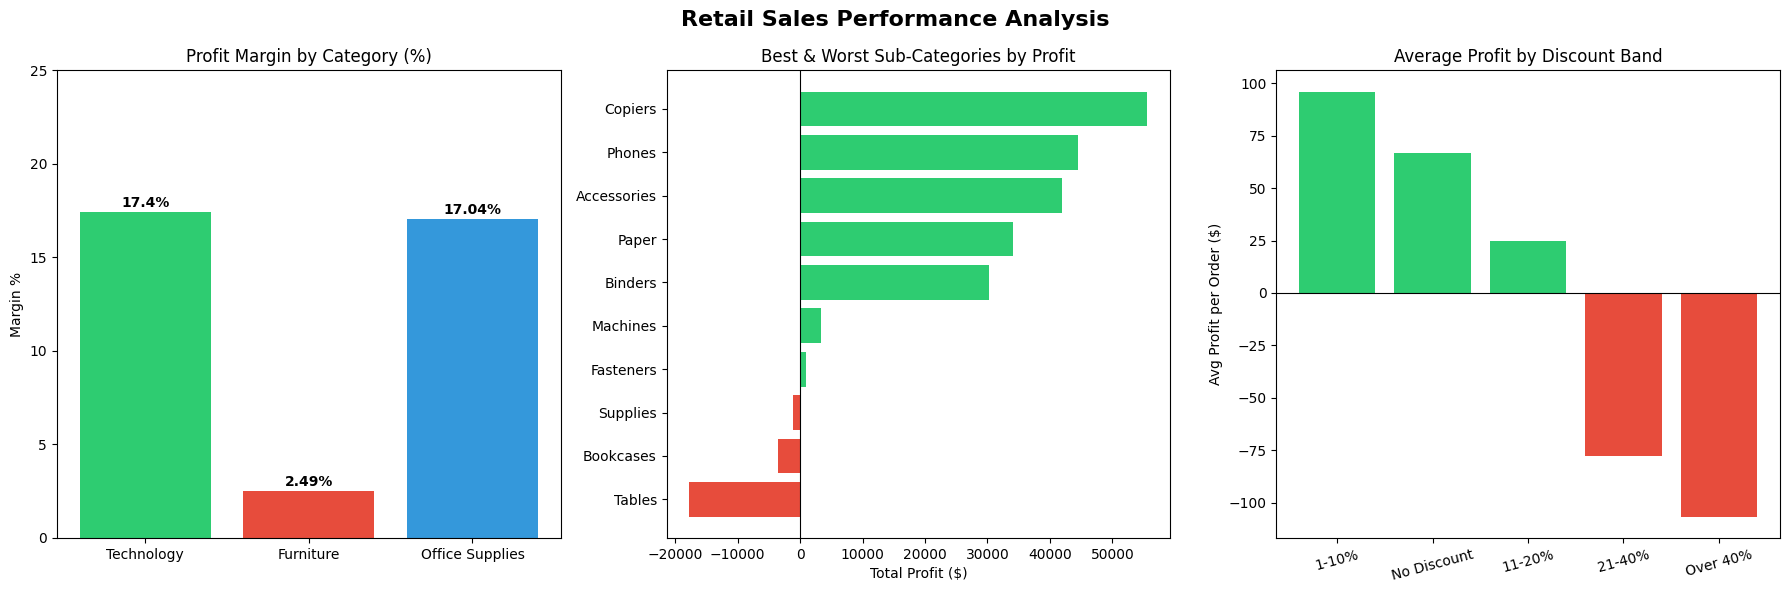

Chart saved.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Retail Sales Performance Analysis', fontsize=16, fontweight='bold')

# Chart 1 — Category Margin
axes[0].bar(category_revenue['Category'], category_revenue['margin_pct'],
            color=['#2ecc71', '#e74c3c', '#3498db'])
axes[0].set_title('Profit Margin by Category (%)')
axes[0].set_ylabel('Margin %')
axes[0].set_ylim(0, 25)
for i, v in enumerate(category_revenue['margin_pct']):
    axes[0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Chart 2 — Sub-Category Profit (bottom 5 vs top 5)
top5 = subcategory.tail(5)
bottom5 = subcategory.head(5)
highlight = pd.concat([bottom5, top5])
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in highlight['profit']]
axes[1].barh(highlight['Sub-Category'], highlight['profit'], color=colors)
axes[1].set_title('Best & Worst Sub-Categories by Profit')
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)

# Chart 3 — Discount Impact
colors3 = ['#2ecc71' if x >= 0 else '#e74c3c' for x in discount_analysis['avg_profit']]
axes[2].bar(discount_analysis['discount_band'], discount_analysis['avg_profit'], color=colors3)
axes[2].set_title('Average Profit by Discount Band')
axes[2].set_ylabel('Avg Profit per Order ($)')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [6]:
mkdir outputs

A subdirectory or file outputs already exists.


## 4. Monthly Revenue Trend
How does revenue and profit move over time? Are there seasonal patterns?

In [7]:
# Monthly revenue trend
monthly_revenue = pd.read_sql_query("""
    SELECT 
        strftime('%Y-%m', "Order Date") AS month,
        ROUND(SUM(Sales), 2) AS monthly_revenue,
        ROUND(SUM(Profit), 2) AS monthly_profit
    FROM orders
    GROUP BY month
    ORDER BY month
""", conn)

print(monthly_revenue)

  month  monthly_revenue  monthly_profit
0  None       2297200.86       286397.02


In [8]:
# Check what the date format actually looks like
print(df['Order Date'].head(10))

0     11/8/2016
1     11/8/2016
2     6/12/2016
3    10/11/2015
4    10/11/2015
5      6/9/2014
6      6/9/2014
7      6/9/2014
8      6/9/2014
9      6/9/2014
Name: Order Date, dtype: str


In [9]:
# Parse dates in pandas and extract year-month
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month'] = df['Order Date'].dt.to_period('M').astype(str)

# Reload into database with fixed dates
df.to_sql('orders', conn, if_exists='replace', index=False)

# Now run the monthly query
monthly_revenue = pd.read_sql_query("""
    SELECT 
        month,
        ROUND(SUM(Sales), 2) AS monthly_revenue,
        ROUND(SUM(Profit), 2) AS monthly_profit
    FROM orders
    GROUP BY month
    ORDER BY month
""", conn)

print(monthly_revenue)

      month  monthly_revenue  monthly_profit
0   2014-01         14236.90         2450.19
1   2014-02          4519.89          862.31
2   2014-03         55691.01          498.73
3   2014-04         28295.35         3488.84
4   2014-05         23648.29         2738.71
5   2014-06         34595.13         4976.52
6   2014-07         33946.39         -841.48
7   2014-08         27909.47         5318.10
8   2014-09         81777.35         8328.10
9   2014-10         31453.39         3448.26
10  2014-11         78628.72         9292.13
11  2014-12         69545.62         8983.57
12  2015-01         18174.08        -3281.01
13  2015-02         11951.41         2813.85
14  2015-03         38726.25         9732.10
15  2015-04         34195.21         4187.50
16  2015-05         30131.69         4667.87
17  2015-06         24797.29         3335.56
18  2015-07         28765.33         3288.65
19  2015-08         36898.33         5355.81
20  2015-09         64595.92         8209.16
21  2015-1

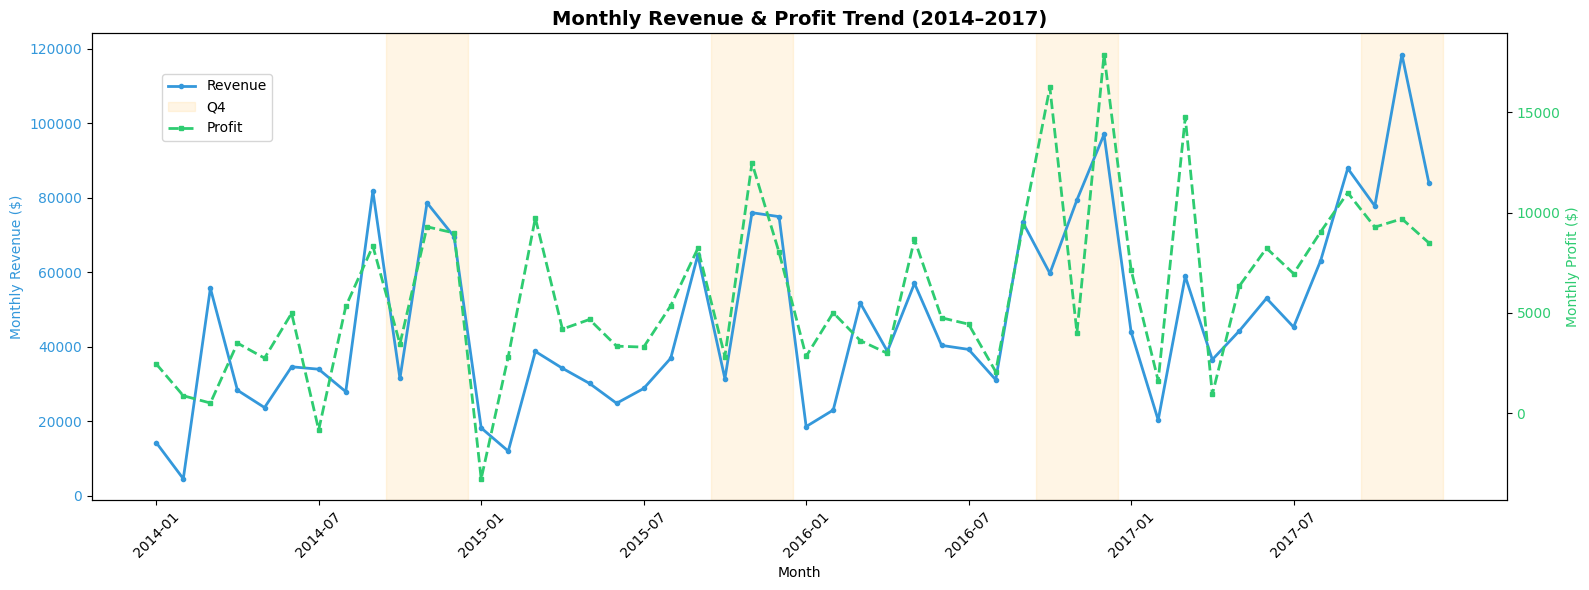

Chart saved.


In [10]:
# Monthly Revenue Trend Chart
fig, ax1 = plt.subplots(figsize=(16, 6))

ax1.plot(monthly_revenue['month'], monthly_revenue['monthly_revenue'], 
         color='#3498db', linewidth=2, marker='o', markersize=3, label='Revenue')
ax1.set_ylabel('Monthly Revenue ($)', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xlabel('Month')

# Overlay profit line on second axis
ax2 = ax1.twinx()
ax2.plot(monthly_revenue['month'], monthly_revenue['monthly_profit'],
         color='#2ecc71', linewidth=2, linestyle='--', marker='s', markersize=3, label='Profit')
ax2.set_ylabel('Monthly Profit ($)', color='#2ecc71')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

# X axis formatting
every_6 = range(0, len(monthly_revenue), 6)
ax1.set_xticks(list(every_6))
ax1.set_xticklabels([monthly_revenue['month'].iloc[i] for i in every_6], rotation=45)

# Highlight Q4 seasonality
for year in ['2014', '2015', '2016', '2017']:
    q4_months = monthly_revenue[monthly_revenue['month'].str.startswith(year)].iloc[9:12]
    if not q4_months.empty:
        ax1.axvspan(q4_months.index[0]-0.5, q4_months.index[-1]+0.5, 
                    alpha=0.1, color='orange', label='Q4' if year=='2014' else '')

ax1.set_title('Monthly Revenue & Profit Trend (2014–2017)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig('outputs/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Key Findings & Recommendations

**Findings:**
- Furniture has a 2.49% margin vs Technology's 17.4% — driven by Tables losing $17,725
  
- Discounts above 20% generate negative profit on average (`$-78 to $-107`)

- Q4 consistently produces revenue spikes across all years — clear seasonality

**Recommendations:**
1. Cap discounts at 20% across all categories, particularly Furniture
2. Review Tables pricing and supplier costs — consider discontinuing or repricing
3. Increase inventory and marketing spend ahead of Q4 each year
4. Double down on Copiers and Accessories — highest profit with strong margins